In [1]:
import pandas as pd
import glob as glob
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import gpplot as gpp
import scipy
from scipy.stats import norm 
from statsmodels.stats.multitest import multipletests
from matplotlib_venn import venn2,venn3  
from matplotlib_venn.layout.venn3 import DefaultLayoutAlgorithm
from sklearn.metrics import roc_curve, auc

gpp.set_aesthetics(context = 'paper')
pd.options.mode.chained_assignment = None

Comparing the results of various hit-calling methods on Brunello, Jacquere screening data. The Z-score method is calculated in the Jacquere Screen Performance section, and hit-calling with the MAGeCK-RRA and MAGeCK-MLE methods are detailed in the run_mageck notebooks in this section. The files read below are the direct outputs of running these methods.

Analysis done in close collaboration with Smriti Srikanth


In [2]:
zscore= pd.read_csv("../../6. Jacquere Screen Performance/Data/jacquere_brunello_A375_zscoremethod.csv")

jacquere_zscore_results=zscore[zscore["condition"]=="Jacquere A375"]
jacquere_mageck_RRA_results=pd.read_table("../Data/jacquere_A375_mageck_RRA_results.gene_summary.txt")
jacquere_mageck_MLE_results=pd.read_table("../Data/jacquere_A375_mageck_MLE_results.gene_summary.txt")

brunello_zscore_results=zscore[zscore["condition"]=="Brunello A375"]
brunello_mageck_RRA_results=pd.read_table("../Data/brunello_A375_mageck_RRA_results.gene_summary.txt") 
brunello_mageck_MLE_results=pd.read_table("../Data/brunello_A375_mageck_MLE_results.gene_summary.txt") 

In [3]:
def process_hitcalling_results(zscore_df,mageck_RRA_df, mageck_MLE_df):
    '''
    Inputs: Dataframes with results of the z-score method,MAGeCK-RRA, and MAGeCK-MLE on the same CRISPR screen 
    Harmonizes formatting and calculates empirical p-value using negative control pseudogenes
    Output: Dataframe that concatenates the results of all three methods for compatibility with plots, downstream analysis 
    '''    
    mageck_RRA_df['method'] = 'MAGeCK RRA'
    mageck_RRA_df['n_sgrnas'] = mageck_RRA_df['num']
    mageck_RRA_df = mageck_RRA_df.rename(columns = {'id':'Gene'})
    #identify null distributions for positive and negative selection enrichment scores 
    pseudogene_negativeselection_score_distribution=scipy.stats.gaussian_kde(mageck_RRA_df[mageck_RRA_df['Gene'].str.contains('Pseudogene')]["neg|score"]) 
    #significance is AUC between 0 (or 1) and a given enrichment score since enrichment scores are bounded (0,1)
    mageck_RRA_df['empirical_pvalue_negativeselection'] = mageck_RRA_df["neg|score"].apply(lambda x: np.min([pseudogene_negativeselection_score_distribution.integrate_box_1d(0, x),pseudogene_negativeselection_score_distribution.integrate_box_1d(x,1)]))
    pseudogene_positiveselection_score_distribution=scipy.stats.gaussian_kde(mageck_RRA_df[mageck_RRA_df['Gene'].str.contains('Pseudogene')]["pos|score"]) 
    mageck_RRA_df['empirical_pvalue_positiveselection'] = mageck_RRA_df["pos|score"].apply(lambda x: np.min([pseudogene_positiveselection_score_distribution.integrate_box_1d(-0, x),pseudogene_positiveselection_score_distribution.integrate_box_1d(x,1)]))
    #take the smaller empirical p-value of negative and positive selection 
    mageck_RRA_df["empirical_pvalue"]=mageck_RRA_df.apply(lambda x: np.min([x["empirical_pvalue_positiveselection"],x["empirical_pvalue_negativeselection"]]),axis=1)
    mageck_RRA_df["selection"]=mageck_RRA_df.apply(lambda x: "negative" if x["neg|score"]<x["pos|score"] else "positive",axis=1)
    mageck_RRA_df['FDR']=multipletests(mageck_RRA_df["empirical_pvalue"].tolist(),method="fdr_bh")[1]
    mageck_RRA_df = mageck_RRA_df[['Gene','n_sgrnas','method',"selection",'FDR']]

    mageck_MLE_df['method'] = 'MAGeCK MLE'
    mageck_MLE_df['n_sgrnas'] = mageck_MLE_df['sgRNA']
    beta_cols = [col for col in mageck_MLE_df.columns if 'beta' in col]
    mageck_MLE_df["beta"]=mageck_MLE_df[beta_cols].mean(axis=1)
    mageck_MLE_df["selection"]=mageck_MLE_df["beta"].apply(lambda x: "negative" if x<0 else "positive")
    pseudogene_score_distribution=scipy.stats.gaussian_kde(mageck_MLE_df[mageck_MLE_df['Gene'].str.contains('Pseudogene')]["beta"]) 
    mageck_MLE_df['empirical_pvalue'] = mageck_MLE_df["beta"].apply(lambda x: np.min([pseudogene_score_distribution.integrate_box_1d(-np.inf, x),pseudogene_score_distribution.integrate_box_1d(x,np.inf)]))
    mageck_MLE_df['FDR']=multipletests(mageck_MLE_df["empirical_pvalue"].tolist(),method="fdr_bh")[1]
    mageck_MLE_df = mageck_MLE_df[['Gene','n_sgrnas','method',"selection",'FDR']]
    
    zscore_df['method']='Z-Score'
    zscore_df["selection"]=zscore_df["gene_zscore"].apply(lambda x: "positive" if x >0 else "negative")
    #empirical p-value,FDR already calculated in jacquere screen analysis notebook 
    zscore_df=zscore_df.rename(columns={"Target Gene Symbol":"Gene"})
    zscore_df = zscore_df[['Gene','n_sgrnas','method',"selection",'FDR']]

    return pd.concat([zscore_df,mageck_RRA_df,mageck_MLE_df])


In [4]:
brunello_hitcallingresults=process_hitcalling_results(brunello_zscore_results,brunello_mageck_RRA_results,brunello_mageck_MLE_results)
jacquere_hitcallingresults=process_hitcalling_results(jacquere_zscore_results,jacquere_mageck_RRA_results,jacquere_mageck_MLE_results)

## Part I: Identifying agreement/disagreement in Jacquere screen hits across methods

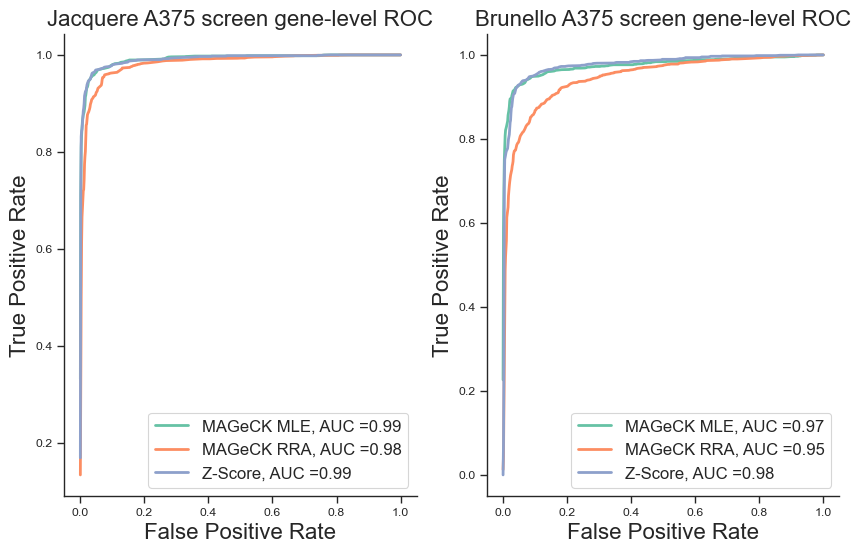

In [90]:
#ROC-AUC upon gene FDRs of hit calling methods
#true positives and negatives defined by sets of common essential and nonessential genes (Hart 2014, Hart 2015)

noness_genes = pd.read_csv("../../6. Jacquere Screen Performance/Data/AchillesNonessentialControls.csv")
noness_genes["Gene"]=noness_genes["Gene"].apply(lambda x: x.split("(")[0]).str.replace(" ","")
essential_genes = pd.read_csv("../../6. Jacquere Screen Performance/Data/AchillesCommonEssentialControls.csv")
essential_genes["Gene"]=essential_genes["Gene"].apply(lambda x: x.split("(")[0]).str.replace(" ","")
jacquere_hitcallingresults['Essential'] = jacquere_hitcallingresults['Gene'].isin(essential_genes["Gene"].tolist())
jacquere_hitcallingresults['Nonessential'] = jacquere_hitcallingresults['Gene'].isin(noness_genes["Gene"].tolist())

ROC_AUC_df= jacquere_hitcallingresults[jacquere_hitcallingresults["Essential"]|jacquere_hitcallingresults["Nonessential"]]
tpr_fpr_df_list = []
roc_auc_list = []
for group, df in ROC_AUC_df.groupby('method'):
    fpr, tpr, threshold = roc_curve(df['Essential'], -df['FDR'])
    group_tpr_fpr_df = pd.DataFrame({'True Positive Rate': tpr, 'False Positive Rate': fpr, 'threshold': threshold})
    group_tpr_fpr_df['method'] = group
    tpr_fpr_df_list.append(group_tpr_fpr_df)
    roc_auc = auc(fpr, tpr)
    roc_auc_list.append({'method': group, 'ROC-AUC': roc_auc})
roc_aucs = pd.DataFrame(roc_auc_list)
tpr_fpr_df = (pd.concat(tpr_fpr_df_list).reset_index(drop=True))

ROC_AUC_map = roc_aucs.set_index('method').to_dict()
tpr_fpr_df['ROC-AUC'] = tpr_fpr_df['method'].map(ROC_AUC_map["ROC-AUC"])
tpr_fpr_df["method"]=tpr_fpr_df['method']+", AUC ="+round(tpr_fpr_df['ROC-AUC'],2).astype(str)

(fig,ax)=plt.subplots(1,2,figsize=(10, 6))
sns.lineplot(data=tpr_fpr_df, x='False Positive Rate', linewidth=2,
             y='True Positive Rate', hue='method', errorbar=None,ax=ax[0])
ax[0].legend(fontsize=12)
ax[0].set_xlabel(xlabel="False Positive Rate",fontsize=16)
ax[0].set_ylabel(ylabel="True Positive Rate",fontsize=16)
ax[0].set_title("Jacquere A375 screen gene-level ROC",fontsize=16)

brunello_hitcallingresults['Essential'] = brunello_hitcallingresults['Gene'].isin(essential_genes["Gene"].tolist())
brunello_hitcallingresults['Nonessential'] = brunello_hitcallingresults['Gene'].isin(noness_genes["Gene"].tolist())

ROC_AUC_df= brunello_hitcallingresults[brunello_hitcallingresults["Essential"]|brunello_hitcallingresults["Nonessential"]]
tpr_fpr_df_list = []
roc_auc_list = []
for group, df in ROC_AUC_df.groupby('method'):
    fpr, tpr, threshold = roc_curve(df['Essential'], -df['FDR'])
    group_tpr_fpr_df = pd.DataFrame({'True Positive Rate': tpr, 'False Positive Rate': fpr, 'threshold': threshold})
    group_tpr_fpr_df['method'] = group
    tpr_fpr_df_list.append(group_tpr_fpr_df)
    roc_auc = auc(fpr, tpr)
    roc_auc_list.append({'method': group, 'ROC-AUC': roc_auc})
roc_aucs = pd.DataFrame(roc_auc_list)
tpr_fpr_df = (pd.concat(tpr_fpr_df_list).reset_index(drop=True))

ROC_AUC_map = roc_aucs.set_index('method').to_dict()
tpr_fpr_df['ROC-AUC'] = tpr_fpr_df['method'].map(ROC_AUC_map["ROC-AUC"])
tpr_fpr_df["method"]=tpr_fpr_df['method']+", AUC ="+round(tpr_fpr_df['ROC-AUC'],2).astype(str)

sns.lineplot(data=tpr_fpr_df, x='False Positive Rate', linewidth=2,
             y='True Positive Rate', hue='method', errorbar=None,ax=ax[1])
ax[1].legend(fontsize=12)
ax[1].set_xlabel(xlabel="False Positive Rate",fontsize=16)
ax[1].set_ylabel(ylabel="True Positive Rate",fontsize=16)
ax[1].set_title("Brunello A375 screen gene-level ROC",fontsize=16)

sns.despine()
gpp.savefig("../Figures/ROC_byhitcallingmethod.pdf",bbox_inches="tight")

In [6]:
jacquere_negative_selection_hits= jacquere_hitcallingresults[(jacquere_hitcallingresults["FDR"]<0.05)&(jacquere_hitcallingresults["selection"]=="negative")].reset_index(drop=True)
unique_jacquere_hits=jacquere_negative_selection_hits.drop_duplicates(subset="Gene",keep=False)
percent_unique_jacquere_hits_belowquota_mle=round(100*len(unique_jacquere_hits[(unique_jacquere_hits["n_sgrnas"]<3)&(unique_jacquere_hits["method"]=="MAGeCK MLE")])/len(unique_jacquere_hits[unique_jacquere_hits["method"]=="MAGeCK MLE"]),1)
percent_unique_jacquere_hits_belowquota_rra=round(100*len(unique_jacquere_hits[(unique_jacquere_hits["n_sgrnas"]<3)&(unique_jacquere_hits["method"]=="MAGeCK RRA")])/len(unique_jacquere_hits[unique_jacquere_hits["method"]=="MAGeCK RRA"]),1)
percent_unique_jacquere_hits_belowquota_zscore=round(100*len(unique_jacquere_hits[(unique_jacquere_hits["n_sgrnas"]<3)&(unique_jacquere_hits["method"]=="Z-Score")])/len(unique_jacquere_hits[unique_jacquere_hits["method"]=="Z-Score"]),1)
print("% MAGeCK MLE unique hits with <3 guides per gene:",percent_unique_jacquere_hits_belowquota_mle,
      "\n% MAGeCK RRA unique hits with <3 guides per gene:",percent_unique_jacquere_hits_belowquota_rra,
      "\n% Z-score method unique hits with <3 guides per gene:",percent_unique_jacquere_hits_belowquota_zscore)

#hits unique to the MLE method are largely below quota, thus, only keep genes with 3 guides for interesting analysis  
jacquere_negative_selection_hits=jacquere_negative_selection_hits[jacquere_negative_selection_hits["n_sgrnas"]==3]


% MAGeCK MLE unique hits with <3 guides per gene: 66.7 
% MAGeCK RRA unique hits with <3 guides per gene: 0.3 
% Z-score method unique hits with <3 guides per gene: 6.5


Jacquere false negative rates: 0.09991941982272357 0.11845286059629334 0.10475423045930699
Brunello false negative rates: 0.18644067796610164 0.192090395480226 0.1832122679580307
Jacquere false negative rates: 0.02356020942408377 0.031413612565445025 0.01963350785340314
Brunello false negative rates: 0.005188067444876783 0.02594033722438392 0.005188067444876783


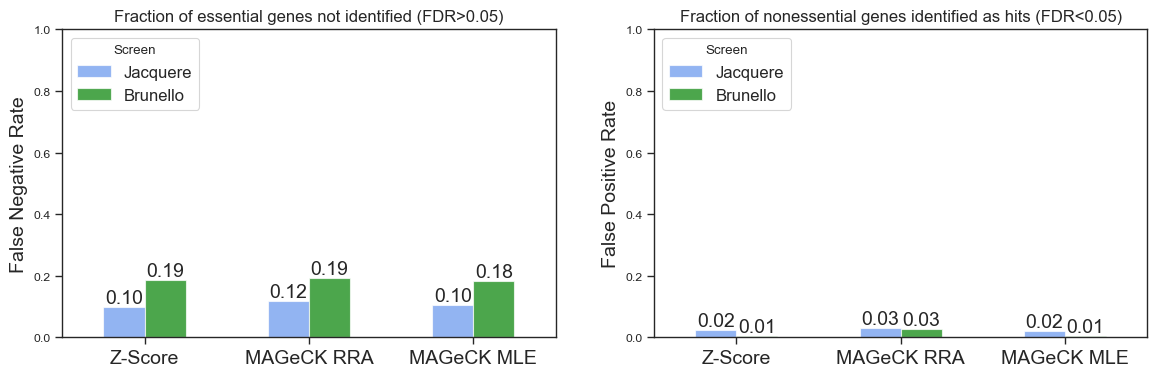

In [98]:
#determining the false positive rate, false negative rate at FDR<0.05 cutoff 
#Jacquere
num_essential_genes_jacquere=len(jacquere_hitcallingresults[jacquere_hitcallingresults['Essential']]["Gene"].unique())
jacquere_essential_negative_selection_hits= jacquere_negative_selection_hits[jacquere_negative_selection_hits["Essential"]]
jacquere_essential_negative_selection_hits_zscore= jacquere_essential_negative_selection_hits[jacquere_essential_negative_selection_hits["method"]=="Z-Score"]["Gene"].tolist()
jacquere_essential_negative_selection_hits_mageckRRA= jacquere_essential_negative_selection_hits[jacquere_essential_negative_selection_hits["method"]=="MAGeCK RRA"]["Gene"].tolist()
jacquere_essential_negative_selection_hits_mageckMLE= jacquere_essential_negative_selection_hits[jacquere_essential_negative_selection_hits["method"]=="MAGeCK MLE"]["Gene"].tolist()

num_nonessential_genes_jacquere=len(jacquere_hitcallingresults[jacquere_hitcallingresults['Nonessential']]["Gene"].unique())
jacquere_nonessential_negative_selection_hits= jacquere_negative_selection_hits[jacquere_negative_selection_hits["Nonessential"]]
jacquere_nonessential_negative_selection_hits_zscore= jacquere_nonessential_negative_selection_hits[jacquere_nonessential_negative_selection_hits["method"]=="Z-Score"]["Gene"].tolist()
jacquere_nonessential_negative_selection_hits_mageckRRA= jacquere_nonessential_negative_selection_hits[jacquere_nonessential_negative_selection_hits["method"]=="MAGeCK RRA"]["Gene"].tolist()
jacquere_nonessential_negative_selection_hits_mageckMLE= jacquere_nonessential_negative_selection_hits[jacquere_nonessential_negative_selection_hits["method"]=="MAGeCK MLE"]["Gene"].tolist()

#Brunello
brunello_negative_selection_hits= brunello_hitcallingresults[(brunello_hitcallingresults["FDR"]<0.05)&(brunello_hitcallingresults["selection"]=="negative")]
brunello_negative_selection_hits=brunello_negative_selection_hits[brunello_negative_selection_hits["n_sgrnas"]==4]

num_essential_genes_brunello=len(brunello_hitcallingresults[brunello_hitcallingresults['Essential']]["Gene"].unique())
brunello_essential_negative_selection_hits= brunello_negative_selection_hits[brunello_negative_selection_hits["Essential"]]
brunello_essential_negative_selection_hits_zscore= brunello_essential_negative_selection_hits[brunello_essential_negative_selection_hits["method"]=="Z-Score"]["Gene"].tolist()
brunello_essential_negative_selection_hits_mageckRRA= brunello_essential_negative_selection_hits[brunello_essential_negative_selection_hits["method"]=="MAGeCK RRA"]["Gene"].tolist()
brunello_essential_negative_selection_hits_mageckMLE= brunello_essential_negative_selection_hits[brunello_essential_negative_selection_hits["method"]=="MAGeCK MLE"]["Gene"].tolist()

num_nonessential_genes_brunello=len(brunello_hitcallingresults[brunello_hitcallingresults['Nonessential']]["Gene"].unique())
brunello_nonessential_negative_selection_hits= brunello_negative_selection_hits[brunello_negative_selection_hits["Nonessential"]]
brunello_nonessential_negative_selection_hits_zscore= brunello_nonessential_negative_selection_hits[brunello_nonessential_negative_selection_hits["method"]=="Z-Score"]["Gene"].tolist()
brunello_nonessential_negative_selection_hits_mageckRRA= brunello_nonessential_negative_selection_hits[brunello_nonessential_negative_selection_hits["method"]=="MAGeCK RRA"]["Gene"].tolist()
brunello_nonessential_negative_selection_hits_mageckMLE= brunello_nonessential_negative_selection_hits[brunello_nonessential_negative_selection_hits["method"]=="MAGeCK MLE"]["Gene"].tolist()


jacquere_zscore_fnr=1-len(jacquere_essential_negative_selection_hits_zscore)/num_essential_genes_jacquere
jacquere_rra_fnr=1-len(jacquere_essential_negative_selection_hits_mageckRRA)/num_essential_genes_jacquere
jacquere_mle_fnr=1-len(jacquere_essential_negative_selection_hits_mageckMLE)/num_essential_genes_jacquere
print("Jacquere false negative rates:",jacquere_zscore_fnr,jacquere_rra_fnr,jacquere_mle_fnr)

brunello_zscore_fnr=1-len(brunello_essential_negative_selection_hits_zscore)/num_essential_genes_brunello
brunello_rra_fnr=1-len(brunello_essential_negative_selection_hits_mageckRRA)/num_essential_genes_brunello
brunello_mle_fnr=1-len(brunello_essential_negative_selection_hits_mageckMLE)/num_essential_genes_brunello
print("Brunello false negative rates:",brunello_zscore_fnr,brunello_rra_fnr,brunello_mle_fnr)

false_negative_rate_df= pd.DataFrame(data={"Jacquere":[jacquere_zscore_fnr,jacquere_rra_fnr,jacquere_mle_fnr],
                                   "Brunello":[brunello_zscore_fnr,brunello_rra_fnr,brunello_mle_fnr],
                                          "Method":["Z-Score","MAGeCK RRA","MAGeCK MLE"]})

jacquere_zscore_fpr=len(jacquere_nonessential_negative_selection_hits_zscore)/num_nonessential_genes_jacquere
jacquere_rra_fpr=len(jacquere_nonessential_negative_selection_hits_mageckRRA)/num_nonessential_genes_jacquere
jacquere_mle_fpr=len(jacquere_nonessential_negative_selection_hits_mageckMLE)/num_nonessential_genes_jacquere
print("Jacquere false negative rates:",jacquere_zscore_fpr,jacquere_rra_fpr,jacquere_mle_fpr)

brunello_zscore_fpr=len(brunello_nonessential_negative_selection_hits_zscore)/num_nonessential_genes_brunello
brunello_rra_fpr=len(brunello_nonessential_negative_selection_hits_mageckRRA)/num_nonessential_genes_brunello
brunello_mle_fpr=len(brunello_nonessential_negative_selection_hits_mageckMLE)/num_nonessential_genes_brunello
print("Brunello false negative rates:",brunello_zscore_fpr,brunello_rra_fpr,brunello_mle_fpr)

false_positive_rate_df= pd.DataFrame(data={"Jacquere":[jacquere_zscore_fpr,jacquere_rra_fpr,jacquere_mle_fpr],
                                   "Brunello":[brunello_zscore_fpr,brunello_rra_fpr,brunello_mle_fpr],
                                          "Method":["Z-Score","MAGeCK RRA","MAGeCK MLE"]})

(fig,ax)=plt.subplots(1,2,figsize=(14, 4))
false_negative_rate_df.plot(x='Method',kind='bar',stacked=False,ax=ax[0],color=["cornflowerblue","green"],alpha=0.7)
ax[0].set_ylim(0,1)
ax[0].legend(loc="upper left",fontsize=12,title="Screen")
ax[0].set_xticklabels(ax[0].get_xticklabels(), rotation=0,fontsize=14)
ax[0].set_xlabel("")
ax[0].set_ylabel("False Negative Rate",fontsize=14)
ax[0].bar_label(ax[0].containers[0], fmt = '%1.2f',size=14)
ax[0].bar_label(ax[0].containers[1], fmt = '%1.2f',size=14)
ax[0].set_title("Fraction of essential genes not identified (FDR>0.05)",fontsize=12)


false_positive_rate_df.plot(x='Method',kind='bar',stacked=False,ax=ax[1],color=["cornflowerblue","green"],alpha=0.7)
ax[1].set_ylim(0,1)
ax[1].legend(loc="upper left",fontsize=12,title="Screen")
ax[1].set_xticklabels(ax[0].get_xticklabels(), rotation=0,fontsize=14)
ax[1].set_xlabel("")
ax[1].set_ylabel("False Positive Rate",fontsize=14)
ax[1].bar_label(ax[1].containers[0], fmt = '%1.2f',size=14)
ax[1].bar_label(ax[1].containers[1], fmt = '%1.2f',size=14)
ax[1].set_title("Fraction of nonessential genes identified as hits (FDR<0.05)",fontsize=12)

gpp.savefig("../Figures/FNR_FPR_atFDR5percentcutoff.pdf",bbox_inches="tight")

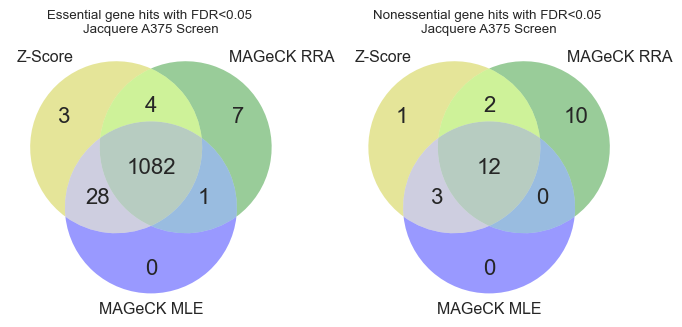

In [87]:
#venn diagrams to identify shared gene hits across methods for jacquere screen

(fig,ax)=plt.subplots(1,2,figsize=(8,4))

v=venn3([set(jacquere_essential_negative_selection_hits_zscore),set(jacquere_essential_negative_selection_hits_mageckRRA),set(jacquere_essential_negative_selection_hits_mageckMLE)],set_labels=('Z-Score','MAGeCK RRA','MAGeCK MLE'),
			layout_algorithm=DefaultLayoutAlgorithm(fixed_subset_sizes=(1,1,1,1,1,1,1)),
          	set_colors= ("y","g","b"),ax=ax[0]) 
for text in v.subset_labels:
    text.set_fontsize(16)
ax[0].set_title("Essential gene hits with FDR<0.05 \nJacquere A375 Screen")

v=venn3([set(jacquere_nonessential_negative_selection_hits_zscore),set(jacquere_nonessential_negative_selection_hits_mageckRRA),set(jacquere_nonessential_negative_selection_hits_mageckMLE)],set_labels=('Z-Score','MAGeCK RRA','MAGeCK MLE'),
			layout_algorithm=DefaultLayoutAlgorithm(fixed_subset_sizes=(1,1,1,1,1,1,1)),
          	set_colors= ("y","g","b"),ax=ax[1]) 
for text in v.subset_labels:
    text.set_fontsize(16)
ax[1].set_title("Nonessential gene hits with FDR<0.05 \nJacquere A375 Screen")


gpp.savefig('../Figures/venn_hitcallingmethods_jacquere_A375.pdf',dpi=600,bbox_inches='tight')

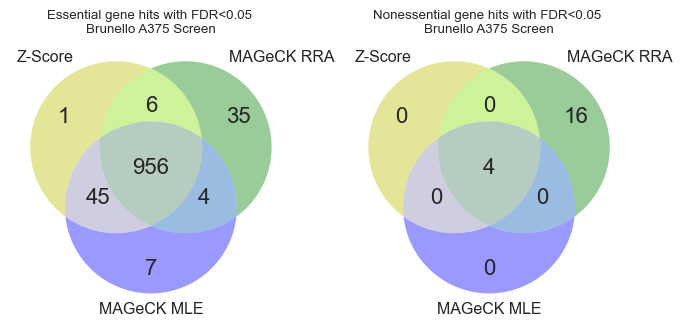

In [88]:
#repeat venn diagrams for brunello screen 
(fig,ax)=plt.subplots(1,2,figsize=(8,4))

v=venn3([set(brunello_essential_negative_selection_hits_zscore),set(brunello_essential_negative_selection_hits_mageckRRA),set(brunello_essential_negative_selection_hits_mageckMLE)],set_labels=('Z-Score','MAGeCK RRA','MAGeCK MLE'),
			layout_algorithm=DefaultLayoutAlgorithm(fixed_subset_sizes=(1,1,1,1,1,1,1)),
          	set_colors= ("y","g","b"),ax=ax[0]) 
for text in v.subset_labels:
    text.set_fontsize(16)
ax[0].set_title("Essential gene hits with FDR<0.05 \nBrunello A375 Screen")

v=venn3([set(brunello_nonessential_negative_selection_hits_zscore),set(brunello_nonessential_negative_selection_hits_mageckRRA),set(brunello_nonessential_negative_selection_hits_mageckMLE)],set_labels=('Z-Score','MAGeCK RRA','MAGeCK MLE'),
			layout_algorithm=DefaultLayoutAlgorithm(fixed_subset_sizes=(1,1,1,1,1,1,1)),
          	set_colors= ("y","g","b"),ax=ax[1]) 
for text in v.subset_labels:
    text.set_fontsize(16)
ax[1].set_title("Nonessential gene hits with FDR<0.05 \nBrunello A375 Screen")

gpp.savefig('../Figures/venn_hitcallingmethods_brunello_A375.pdf',dpi=600,bbox_inches='tight')

/var/folders/nm/6_wl7tx50tq5bqfp8vzf4m6r0000gq/T/ipykernel_5467/1616595350.py:4: DtypeWarning: Columns (3,5,6,7,10,11,12) have mixed types. Specify dtype option on import or set low_memory=False.
  guideinfo=pd.read_csv("../../6. Jacquere Screen Performance/Data/jacquere_brunello_guideinfo.csv")


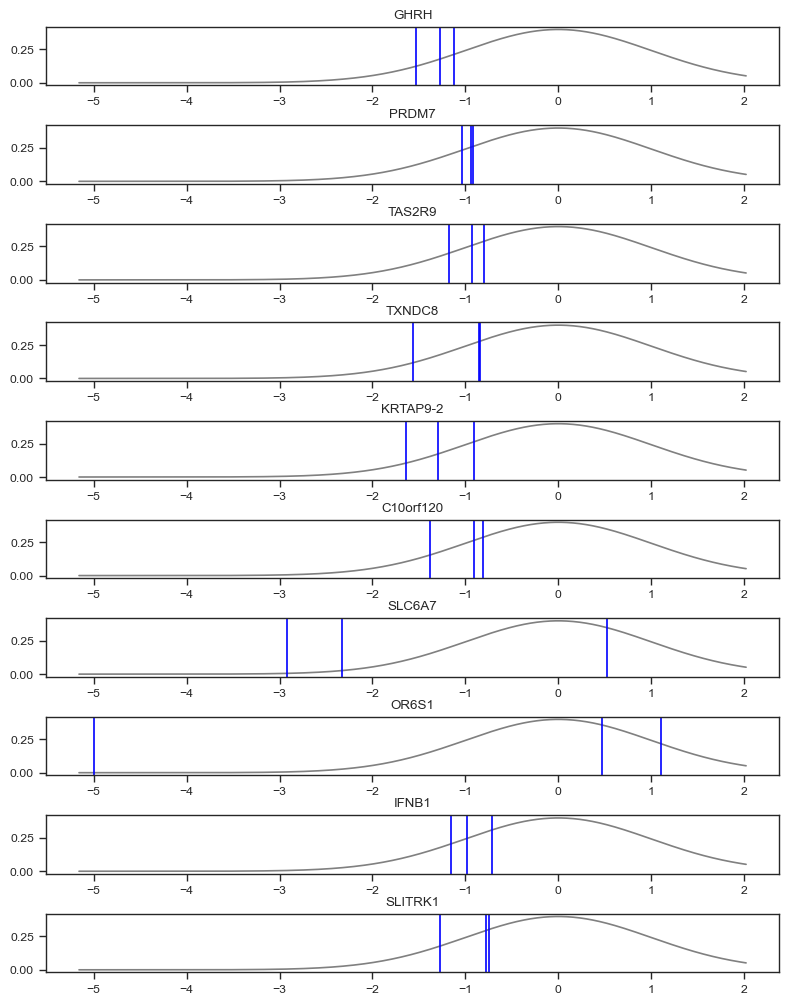

In [10]:
#examining false positives unique to MAGeCK RRA 

falsepositives_RRA= [gene for gene in jacquere_nonessential_negative_selection_hits_mageckRRA if gene not in jacquere_nonessential_negative_selection_hits_zscore and gene not in jacquere_nonessential_negative_selection_hits_mageckMLE]
guideinfo=pd.read_csv("../../6. Jacquere Screen Performance/Data/jacquere_brunello_guideinfo.csv")
jacquere_guideinfo=guideinfo[guideinfo["condition"]=="Jacquere A375"]

intergenic_zscores_jacquere=jacquere_guideinfo[jacquere_guideinfo["Target Gene Symbol"].str.count("_INTERGENIC")>0]["z_scored_sgRNA_lfc"]
intergenic_zscores_jacquere_range=np.arange(intergenic_zscores_jacquere.min(), intergenic_zscores_jacquere.max(), 0.01) 

(fig,ax)=plt.subplots(len(falsepositives_RRA),1,figsize=(8,len(falsepositives_RRA)))
fig.tight_layout()
for i in range(len(falsepositives_RRA)):
    focus_gene=falsepositives_RRA[i]
    ax[i].set_title(focus_gene)
    ax[i].plot(intergenic_zscores_jacquere_range, norm.pdf(intergenic_zscores_jacquere_range,intergenic_zscores_jacquere.mean(),intergenic_zscores_jacquere.std()),color="grey") 
    focus_gene_zscores=jacquere_guideinfo[jacquere_guideinfo["Target Gene Symbol"]==focus_gene]["z_scored_sgRNA_lfc"]
    for zscore in focus_gene_zscores:
        ax[i].axvline(x=zscore,color="blue")
gpp.savefig('../Figures/jacquereguidezscores_MAGeCKRRA_falsepositives.pdf',dpi=600,bbox_inches='tight')

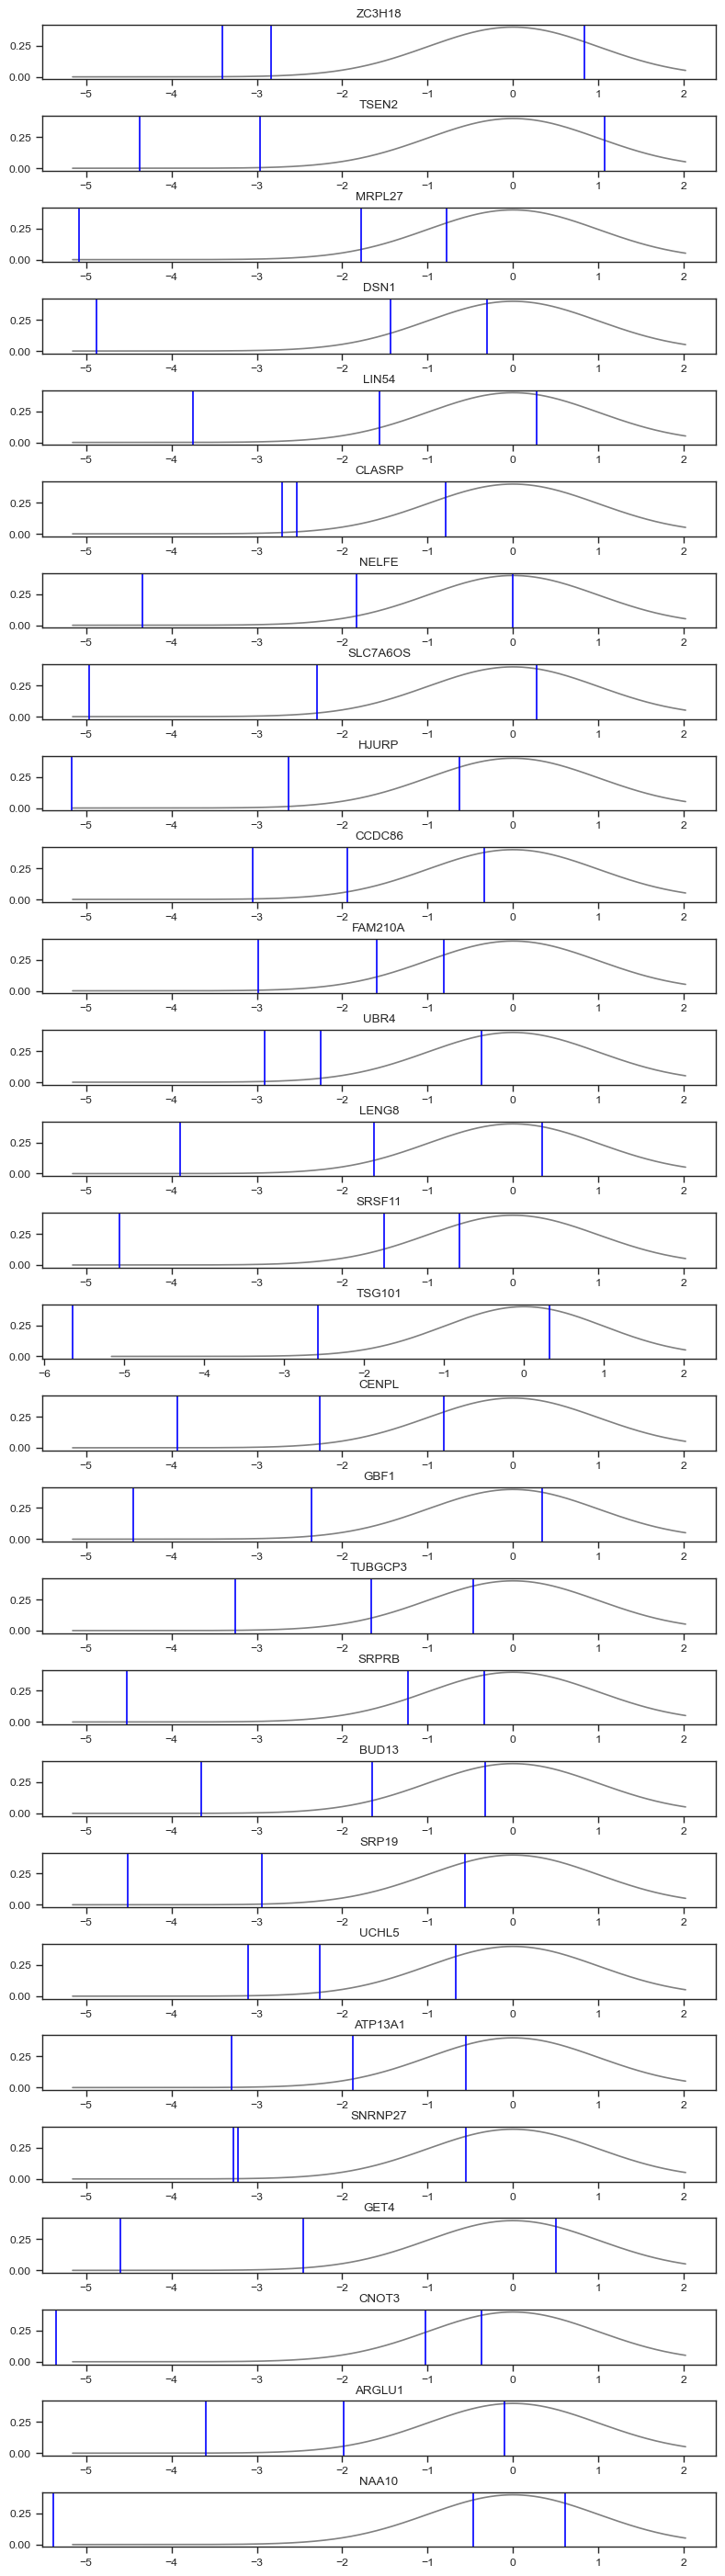

In [11]:
falsenegatives_RRA= [gene for gene in jacquere_essential_negative_selection_hits_mageckMLE if gene in jacquere_essential_negative_selection_hits_zscore and gene not in jacquere_essential_negative_selection_hits_mageckRRA]

(fig,ax)=plt.subplots(len(falsenegatives_RRA),1,figsize=(8,len(falsenegatives_RRA)))
fig.tight_layout()
for i in range(len(falsenegatives_RRA)):
    focus_gene=falsenegatives_RRA[i]
    ax[i].set_title(focus_gene)
    ax[i].plot(intergenic_zscores_jacquere_range, norm.pdf(intergenic_zscores_jacquere_range,intergenic_zscores_jacquere.mean(),intergenic_zscores_jacquere.std()),color="grey") 
    focus_gene_zscores=jacquere_guideinfo[jacquere_guideinfo["Target Gene Symbol"]==focus_gene]["z_scored_sgRNA_lfc"]
    for zscore in focus_gene_zscores:
        ax[i].axvline(x=zscore,color="blue")
gpp.savefig('../Figures/jacquereguidezscores_MAGeCKRRA_falsenegatives.pdf',dpi=600,bbox_inches='tight')


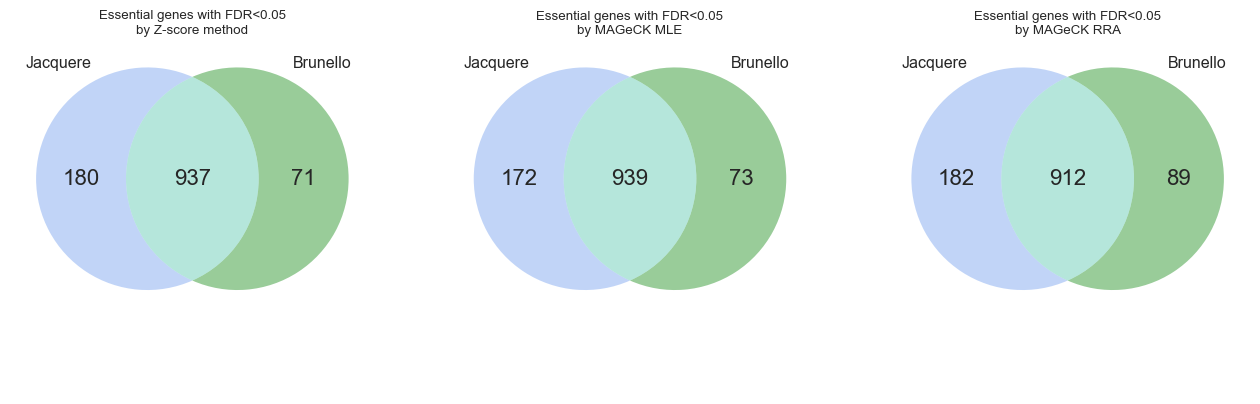

In [12]:
#Identifying agreement/disagreement in hits in Brunello vs. Jacquere for each method

(fig,ax)=plt.subplots(1,3,figsize=(16,8))

v=venn2([set(jacquere_essential_negative_selection_hits_zscore),set(brunello_essential_negative_selection_hits_zscore)],set_labels=('Jacquere','Brunello'),
        layout_algorithm=DefaultLayoutAlgorithm(fixed_subset_sizes=(1,1,1,1,1,1,1)),
        set_colors=("cornflowerblue","green"),ax=ax[0]) 
for text in v.subset_labels:
    text.set_fontsize(16)
ax[0].set_title("Essential genes with FDR<0.05\nby Z-score method")

v=venn2([set(jacquere_essential_negative_selection_hits_mageckMLE),set(brunello_essential_negative_selection_hits_mageckMLE)],set_labels=('Jacquere','Brunello'),
        layout_algorithm=DefaultLayoutAlgorithm(fixed_subset_sizes=(1,1,1,1,1,1,1)),
        set_colors=("cornflowerblue","green"),ax=ax[1]) 
for text in v.subset_labels:
    text.set_fontsize(16)
ax[1].set_title("Essential genes with FDR<0.05\nby MAGeCK MLE")

v=venn2([set(jacquere_essential_negative_selection_hits_mageckRRA),set(brunello_essential_negative_selection_hits_mageckRRA)],set_labels=('Jacquere','Brunello'),
        layout_algorithm=DefaultLayoutAlgorithm(fixed_subset_sizes=(1,1,1,1,1,1,1)),
        set_colors=("cornflowerblue","green"),ax=ax[2]) 
for text in v.subset_labels:
    text.set_fontsize(16)
ax[2].set_title("Essential genes with FDR<0.05\nby MAGeCK RRA")

gpp.savefig('../Figures/library_hit_agreement_by_method.pdf',dpi=600,bbox_inches='tight')